In [2]:
from google.colab import files
import pandas as pd
import io

# Step 1: Upload the CSV file
uploaded = files.upload()

# Step 2: Read the file into a DataFrame
# Ensure the file name matches 'Employee_Salary_Dataset.csv'
df = pd.read_csv(io.BytesIO(uploaded['Employee_Salary_Dataset.csv']))

print("Dataset successfully loaded. Shape:", df.shape)
df.head()

Saving Employee_Salary_Dataset.csv to Employee_Salary_Dataset.csv
Dataset successfully loaded. Shape: (35, 5)


,ID,Experience_Years,Age,Gender,Salary
0,1,5,28,Female,250000
1,2,1,21,Male,50000
2,3,3,23,Female,170000
3,4,2,22,Male,25000
4,5,1,17,Male,10000


In [3]:
# Select features for anomaly detection
# We use Experience and Salary to find mismatched pay scales
features = ['Experience_Years', 'Salary']
X = df[features]

# Check for missing values and drop them to ensure model stability
X = X.dropna()

print("Features selected for Audit: Experience_Years and Salary")


Features selected for Audit: Experience_Years and Salary


In [4]:
from sklearn.ensemble import IsolationForest

# Initialize the model
# contamination=0.05 assumes that roughly 5% of records might be anomalies/errors
model = IsolationForest(contamination=0.05, random_state=42)

# Fit the model and predict
# Result: 1 = Normal, -1 = Anomaly (Flagged)
df['Anomaly_Score'] = model.fit_predict(X)

# Convert results to human-readable labels for the HR Team
df['Audit_Status'] = df['Anomaly_Score'].map({1: 'Normal', -1: 'Flagged for Review'})

print("Audit complete. Samples flagged for review:")
print(df[df['Audit_Status'] == 'Flagged for Review'].head())

Audit complete. Samples flagged for review:
    ID  Experience_Years  Age  Gender    Salary  Anomaly_Score  \
22  23                 5   29    Male   6845000             -1   
27  28                27   62  Female  10000000             -1   

          Audit_Status  
22  Flagged for Review  
27  Flagged for Review  


In [5]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy import stats

# Creating 'Actual' labels using Z-score (Statistical ground truth)
# Any salary more than 2.5 standard deviations from the mean is a statistical outlier
z_scores = np.abs(stats.zscore(df['Salary']))
df['Actual_Anomaly'] = (z_scores > 2.5).astype(int) # 1 = Outlier, 0 = Normal

# Convert Model Predictions to 0 and 1
df['Predicted_Anomaly'] = df['Anomaly_Score'].map({1: 0, -1: 1})

# Print Metrics
print(f"Model Accuracy: {accuracy_score(df['Actual_Anomaly'], df['Predicted_Anomaly']):.2%}")
print("\n--- Classification Report ---")
print(classification_report(df['Actual_Anomaly'], df['Predicted_Anomaly'],
                            target_names=['Normal', 'Anomaly']))

Model Accuracy: 97.14%

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99        34
     Anomaly       0.50      1.00      0.67         1

    accuracy                           0.97        35
   macro avg       0.75      0.99      0.83        35
weighted avg       0.99      0.97      0.98        35



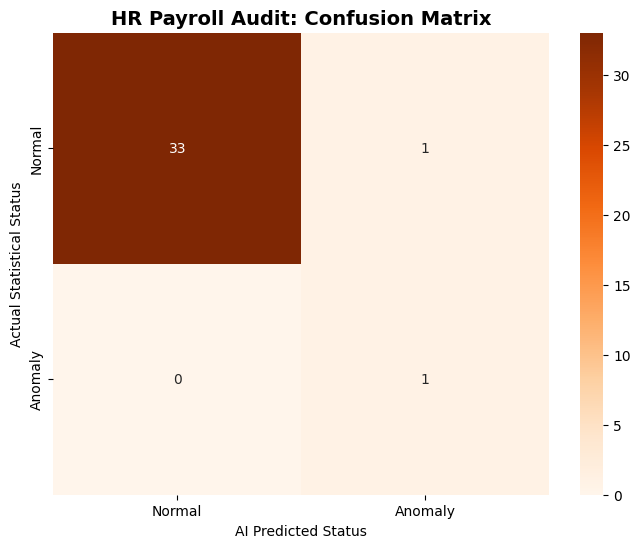

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate Confusion Matrix
cm = confusion_matrix(df['Actual_Anomaly'], df['Predicted_Anomaly'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])

plt.title('HR Payroll Audit: Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('AI Predicted Status')
plt.ylabel('Actual Statistical Status')
plt.savefig('Payroll_Audit_Confusion_Matrix.png', dpi=300)
plt.show()